In [ ]:
# Dependencies

!pip install "transformers==4.46.2"
!pip install gensim
!pip install optuna
!pip install seaborn
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
import torch.nn as nn
import optuna
from transformers import BertModel
from sklearn.metrics import accuracy_score

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.1/44.1 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 22.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 44.0 MB/s eta 0:00:00
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.1
    Uninstalling tokenizers-0.22.1:
      Successfully uninstalled tokenizers-0.22.1
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.3
    Uninstalling transformers-4.57.3:
      Successfully uninstalled transformers-4.57.3
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 44.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 16.7 MB/s eta 0:00:00


In [ ]:
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import Counter
import re

from transformers import BertTokenizer, BertModel, BertConfig
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Task 1

In [ ]:
# --- UPDATED DATA LOADING ---
DATA_DIR = "/content/drive/MyDrive/sample_data/WOS11967"

x_path = f"{DATA_DIR}/X.txt"
y1_path = f"{DATA_DIR}/YL1.txt"
y2_path = f"{DATA_DIR}/Y.txt"  # CHANGED: Use Y.txt instead of YL2.txt
y_path = f"{DATA_DIR}/Y.txt"
with open(x_path, "r") as f:
    x = f.read().splitlines()
with open(y_path, "r") as f:
    y = f.read().splitlines()

# Load Labels
y_l1 = np.loadtxt(y1_path, dtype=int) # Domains (0-6)
y_l2 = np.loadtxt(y2_path, dtype=int) # Global Sub-fields (0-32)

print(f"Y1 (Domains) max value: {y_l1.max()}")
print(f"Y2 (Sub-fields) max value: {y_l2.max()}")


Y1 (Domains) max value: 6
Y2 (Sub-fields) max value: 32


In [ ]:
#Splitting train/validation/test
x_train_val, x_test, y_train_val, y_test, y1_train_val, y1_test, y2_train_val, y2_test = train_test_split(
    x, y, y_l1, y_l2, test_size=0.2, random_state=42)

x_train, x_val, y_train, y_val, y1_train, y1_val, y2_train, y2_val = train_test_split(
    x_train_val, y_train_val, y1_train_val, y2_train_val, test_size=0.2, random_state=42)


print(f"Train size: {len(x_train)}")
print(f"Validation size: {len(x_val)}")
print(f"Test size: {len(x_test)}")


Train size: 7658
Validation size: 1915
Test size: 2394


In [ ]:
# LSTM Tokenization
def simple_tokenize(text):
    # Lowercase
    text = text.lower()
    # Remove non-alphanumeric characters (keep spaces)
    text = re.sub(r'[^a-z0-9\s]', '', text)
    # Split by whitespace
    return text.split()

train_tokens = [simple_tokenize(text) for text in x_train]
val_tokens = [simple_tokenize(text) for text in x_val]
test_tokens = [simple_tokenize(text) for text in x_test]

print("Ex token: ", train_tokens[0][:20])

Ex token:  ['previous', 'research', 'mostly', 'defines', 'the', 'benefits', 'of', 'work', 'as', 'the', 'absence', 'of', 'unemployments', 'negative', 'outcomes', 'or', 'as', 'benefits', 'to', 'employers']


In [ ]:
# encode tokens
counter = Counter()
for tokens in train_tokens:
    counter.update(tokens)

vocab = {"<PAD>": 0, "<UNK>": 1}

for token, count in counter.items():
  if count >= 2:
    vocab[token] = len(vocab)

print(f"Vocab size: {len(vocab)}")

def encode_tokens(tokens, vocab):
    return [vocab.get(token, vocab["<UNK>"]) for token in tokens]

train_encoded = [encode_tokens(tokens, vocab) for tokens in train_tokens]
val_encoded = [encode_tokens(tokens, vocab) for tokens in val_tokens]
test_encoded = [encode_tokens(tokens, vocab) for tokens in test_tokens]


Vocab size: 32874


In [ ]:
# to torch tensors

max_seq_len = 256

def pad_sequences(seq, max_len):
  if len(seq) >= max_len:
    return seq[:max_len]
  return seq + [0] * (max_len - len(seq))

train_padded = [pad_sequences(seq, max_seq_len) for seq in train_encoded]
val_padded = [pad_sequences(seq, max_seq_len) for seq in val_encoded]
test_padded = [pad_sequences(seq, max_seq_len) for seq in test_encoded]

x_train_lstm = torch.tensor(train_padded)
x_val_lstm = torch.tensor(val_padded)
x_test_lstm = torch.tensor(test_padded)

y1_train = torch.tensor(y1_train)
y1_val = torch.tensor(y1_val)
y1_test = torch.tensor(y1_test)

y2_train = torch.tensor(y2_train)
y2_val = torch.tensor(y2_val)
y2_test = torch.tensor(y2_test)

print("Train LSTM tensor shape: ", x_train_lstm.shape)
print("Val LSTM tensor shape: ", x_val_lstm.shape)
print("Test LSTM tensor shape: ", x_test_lstm.shape)

print("Train Y1 tensor shape: ", y1_train.shape)
print("Train Y2 tensor shape: ", y2_train.shape)

Train LSTM tensor shape:  torch.Size([7658, 256])
Val LSTM tensor shape:  torch.Size([1915, 256])
Test LSTM tensor shape:  torch.Size([2394, 256])
Train Y1 tensor shape:  torch.Size([7658])
Train Y2 tensor shape:  torch.Size([7658])


In [ ]:
# LSTM Dataset
# LSTM Dataloader

class WOSLSTMDataset(Dataset):
  def __init__(self, x, y1, y2):
    self.x = x
    self.y1 = y1
    self.y2 = y2

  def __len__(self):
    return len(self.x)

  def __getitem__(self, idx):
    return self.x[idx], self.y1[idx], self.y2[idx]

batch_size = 32

train_dataset_lstm = WOSLSTMDataset(x_train_lstm, y1_train, y2_train)
val_dataset_lstm = WOSLSTMDataset(x_val_lstm, y1_val, y2_val)
test_dataset_lstm = WOSLSTMDataset(x_test_lstm, y1_test, y2_test)

train_loader_lstm = DataLoader(train_dataset_lstm, batch_size=batch_size, shuffle=True)
val_loader_lstm = DataLoader(val_dataset_lstm, batch_size=batch_size, shuffle=False)
test_loader_lstm = DataLoader(test_dataset_lstm, batch_size=batch_size, shuffle=False)

for batch in train_loader_lstm:
  print(batch[0].shape)
  break

torch.Size([32, 256])


In [ ]:
# BERT Preprocessing

def encode_bert(text, tokenizer, max_length=128):
    encoded_dict = tokenizer.encode_plus(
        text,
        add_special_tokens=True,
        max_length=max_length,
        padding="max_length",
        truncation=True,
        return_attention_mask=True,
        return_tensors="pt"
    )
    return encoded_dict

x_train_bert = [encode_bert(text, tokenizer) for text in x_train]
x_val_bert = [encode_bert(text, tokenizer) for text in x_val]
x_test_bert = [encode_bert(text, tokenizer) for text in x_test]

print("Train BERT tensor shape: ", x_train_bert[0]["input_ids"].shape)
print("Ex tokens: ", x_train_bert[0]["input_ids"][0][:20])

# Encode all text into single tensors
input_ids_train = torch.cat([x["input_ids"] for x in x_train_bert], dim=0)
attention_mask_train = torch.cat([x["attention_mask"] for x in x_train_bert], dim=0)

input_ids_val = torch.cat([x["input_ids"] for x in x_val_bert], dim=0)
attention_mask_val = torch.cat([x["attention_mask"] for x in x_val_bert], dim=0)

input_ids_test = torch.cat([x["input_ids"] for x in x_test_bert], dim=0)
attention_mask_test = torch.cat([x["attention_mask"] for x in x_test_bert], dim=0)

print("Train BERT tensor shape: ", input_ids_train.shape)
print("Val BERT tensor shape: ", input_ids_val.shape)



Train BERT tensor shape:  torch.Size([1, 128])
Ex tokens:  tensor([  101,  3025,  2470,  3262, 11859,  1996,  6666,  1997,  2147,  2004,
         1996,  6438,  1997, 12163,  1005,  1055,  4997, 13105,  2030,  2004])
Train BERT tensor shape:  torch.Size([7658, 128])
Val BERT tensor shape:  torch.Size([1915, 128])


In [ ]:
# # BERT Dataset

class WOSBERTDataset(Dataset):
  def __init__(self, input_ids, attention_mask, y1, y2):
    self.input_ids = input_ids
    self.attention_mask = attention_mask
    self.y1 = y1
    self.y2 = y2
  def __len__(self):
    return len(self.input_ids)

  def __getitem__(self, idx):
    return {
        "input_ids": self.input_ids[idx],
        "attention_mask": self.attention_mask[idx],
        "y1": self.y1[idx],
        "y2": self.y2[idx]
    }

batch_size_bert = 16

# Create dataloaders for BERT

train_dataset_bert = WOSBERTDataset(input_ids_train, attention_mask_train, y1_train, y2_train)
val_dataset_bert = WOSBERTDataset(input_ids_val, attention_mask_val, y1_val, y2_val)
test_dataset_bert = WOSBERTDataset(input_ids_test, attention_mask_test, y1_test, y2_test)

train_loader_bert = DataLoader(train_dataset_bert, batch_size=batch_size_bert, shuffle=True)
val_loader_bert = DataLoader(val_dataset_bert, batch_size=batch_size_bert, shuffle=False)
test_loader_bert = DataLoader(test_dataset_bert, batch_size=batch_size_bert, shuffle=False)

batch_bert = next(iter(train_loader_bert))
print("BERT Batch shape: ", batch_bert["input_ids"].shape)
print("BERT Batch label L1 shape: ", batch_bert["y1"].shape)
print("BERT Batch label L2 shape: ", batch_bert["y2"].shape)


BERT Batch shape:  torch.Size([16, 128])
BERT Batch label L1 shape:  torch.Size([16])
BERT Batch label L2 shape:  torch.Size([16])


# Task 2

## LSTM

In [ ]:
import gensim.downloader as api
import shutil
import os

# Clear the corrupted/incomplete download
cache_dir = api.BASE_DIR
print(f"Cache directory: {cache_dir}")

# Remove the corrupted word2vec download
w2v_cache = os.path.join(cache_dir, "word2vec-google-news-300")
if os.path.exists(w2v_cache):
    print("Removing corrupted cache...")
    shutil.rmtree(w2v_cache)

# Also remove any partial .gz files
for file in os.listdir(cache_dir) if os.path.exists(cache_dir) else []:
    if "word2vec" in file.lower():
        os.remove(os.path.join(cache_dir, file))
        print(f"Removed: {file}")

# Try downloading again with fresh start
w2v = api.load("word2vec-google-news-300")
# print("Success!")

Cache directory: /root/gensim-data
[==================================================] 100.0% 1662.8/1662.8MB downloaded
Success!


In [ ]:
# Create embedding matrix from word2vec
embedding_dim = 300
embedding_matrix = np.zeros((len(vocab), embedding_dim))
for word, idx in vocab.items():
  if word in w2v:
    embedding_matrix[idx] = w2v[word]
  else:
    embedding_matrix[idx] = np.random.normal(scale=0.6, size=(embedding_dim,))

In [ ]:
# Create an LSTM (Long Short-Term Memory Network) class from scratch

class LSTM(nn.Module):
  def __init__(self, vocab_size, embed_dim, hidden_size, num_classesY1, num_classesY2, bias=True, padding_idx=0):
    super(LSTM, self).__init__()
    self.input_size = embed_dim
    self.hidden_size = hidden_size
    self.bias = bias

    # 1. Embeddings
    self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
    # Load pretrained embeddings (assuming embedding_matrix exists globally)
    self.embedding.weight = nn.Parameter(torch.tensor(embedding_matrix, dtype=torch.float32))
    self.dropout = nn.Dropout(0.3)

    # 2. LSTM Weights (Manual Implementation)
    self.W_ih = nn.Parameter(torch.randn(4 * hidden_size, self.input_size))
    self.W_hh = nn.Parameter(torch.randn(4 * hidden_size, hidden_size))
    if bias:
      self.b = nn.Parameter(torch.randn(4 * hidden_size))
    else:
      self.b = None

    # 3. Classifiers for Experiment 2 (Hierarchical)
    # FC1: Hidden -> Y1
    self.fc = nn.Linear(hidden_size, num_classesY1)
    # FC2: [Hidden + Y1_Probs] -> Y2
    self.fc2 = nn.Linear(hidden_size + num_classesY1, num_classesY2)

    self.reset_parameters()

  def reset_parameters(self):
    nn.init.xavier_uniform_(self.W_ih)
    nn.init.orthogonal_(self.W_hh)
    if self.b is not None:
      nn.init.constant_(self.b, 0.0)
      self.b.data[self.hidden_size: 2*self.hidden_size] = 1.0 # Forget gate bias
    nn.init.xavier_uniform_(self.fc.weight)
    nn.init.xavier_uniform_(self.fc2.weight)
    nn.init.constant_(self.fc.bias, 0.0)
    nn.init.constant_(self.fc2.bias, 0.0)

  def forward(self, x, hidden=None):
    x = self.embedding(x)
    batch_size, seq_len, _ = x.size()

    if hidden is None:
      h_t = torch.zeros(batch_size, self.hidden_size, device=x.device)
      c_t = torch.zeros(batch_size, self.hidden_size, device=x.device)
    else:
      h_t, c_t = hidden

    outputs = []
    for t in range(seq_len):
      x_t = x[:, t, :]
      gates = x_t @ self.W_ih.t() + h_t @ self.W_hh.t()
      if self.b is not None:
        gates += self.b
      i_t, f_t, g_t, o_t = gates.chunk(4, 1)
      i_t = torch.sigmoid(i_t)
      f_t = torch.sigmoid(f_t)
      g_t = torch.tanh(g_t)
      o_t = torch.sigmoid(o_t)
      c_t = f_t * c_t + i_t * g_t
      h_t = o_t * torch.tanh(c_t)
      outputs.append(h_t.unsqueeze(1))

    outputs = torch.cat(outputs, dim=1)

    # --- UPDATED LOGIC ---
    last_hidden = outputs[:, -1, :]
    last_hidden = self.dropout(last_hidden)

    # Predict Y1
    logits_l1 = self.fc(last_hidden)

    # Create probabilities for Y1 to feed into Y2
    probs_l1 = torch.softmax(logits_l1, dim=1)

    # Concatenate [Hidden, Y1_Probs]
    combined_features = torch.cat((last_hidden, probs_l1), dim=1)

    # Predict Y2
    logits_l2 = self.fc2(combined_features)

    return logits_l1, logits_l2

  def fit(self, train_loader, epochs=5, lr=0.01, device="cpu"):
    self.to(device)
    optimizer = torch.optim.Adam(self.parameters(), lr=lr)
    # Define Loss (assuming class_weights_l1/l2 exist globally)
    criterion_y1 = nn.CrossEntropyLoss(weight=class_weights_l1)
    criterion_y2 = nn.CrossEntropyLoss(weight=class_weights_l2)

    for epoch in range(epochs):
      self.train()
      total_loss = 0
      total = 0
      for batch_X, batch_Y1, batch_Y2 in train_loader:
        batch_X = batch_X.to(device).long()
        batch_Y1 = batch_Y1.to(device)
        batch_Y2 = batch_Y2.to(device)

        optimizer.zero_grad()
        batch_size = batch_X.size(0)

        # Forward returns logits directly now
        logits_l1, logits_l2 = self.forward(batch_X)

        loss_l1 = criterion_y1(logits_l1, batch_Y1)
        loss_l2 = criterion_y2(logits_l2, batch_Y2)
        loss = loss_l1 + loss_l2

        loss.backward()
        nn.utils.clip_grad_norm_(self.parameters(), max_norm=1)
        optimizer.step()

        total_loss += loss.item() * batch_size
        total += batch_size

      # print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/total:.4f}")

  def predict(self, data_loader, device="cpu"):
    self.eval()
    preds_l1, preds_l2 = [], []
    with torch.no_grad():
      for batch_X, _ , _ in data_loader:
        batch_X = batch_X.to(device).long()
        logits_l1, logits_l2 = self.forward(batch_X)
        preds_l1.append(torch.argmax(logits_l1, dim=1).cpu().numpy())
        preds_l2.append(torch.argmax(logits_l2, dim=1).cpu().numpy())
    return np.concatenate(preds_l1), np.concatenate(preds_l2)

  def evaluate(self, y, y_pred):
    y_l1, y_l2 = y
    y_pred_l1, y_pred_l2 = y_pred
    acc_l1 = np.mean(y_l1 == y_pred_l1)
    acc_l2 = np.mean(y_l2 == y_pred_l2)
    f1_l1 = f1_score(y_l1, y_pred_l1, average="macro")
    f1_l2 = f1_score(y_l2, y_pred_l2, average="macro")
    print(f"Acc Y1: {acc_l1:.4f}, Acc Y2: {acc_l2:.4f}")
    print(f"F1 Y1: {f1_l1:.4f}, F1 Y2: {f1_l2:.4f}")
    return acc_l1, acc_l2, f1_l1, f1_l2








### Experiment for better LSTM Y2 results
#### Implementing attention mechanism

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import f1_score

# --- ATTENTION LAYER (New Feature) ---
class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        # A learnable weight matrix to score how "important" each word is
        self.attn = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, lstm_outputs):
        # lstm_outputs shape: [batch_size, seq_len, hidden_size]

        # 1. Calculate scores for every word
        # scores shape: [batch_size, seq_len, 1]
        scores = self.attn(lstm_outputs)

        # 2. Calculate weights (probability distribution over words)
        weights = torch.softmax(scores, dim=1)

        # 3. Calculate Context Vector (Weighted sum of all hidden states)
        # context shape: [batch_size, hidden_size]
        context = torch.sum(weights * lstm_outputs, dim=1)

        return context

# --- UPDATED LSTM WITH ATTENTION ---
class LSTM(nn.Module):
  def __init__(self, vocab_size, embed_dim, hidden_size, num_classesY1, num_classesY2, bias=True, padding_idx=0):
    super(LSTM, self).__init__()
    self.input_size = embed_dim
    self.hidden_size = hidden_size
    self.bias = bias

    # 1. Embeddings
    self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=padding_idx)
    # Load pretrained embeddings if available
    if 'embedding_matrix' in globals():
        self.embedding.weight = nn.Parameter(torch.tensor(embedding_matrix, dtype=torch.float32))

    self.dropout = nn.Dropout(0.3)

    # 2. LSTM Weights (From Scratch Implementation)
    self.W_ih = nn.Parameter(torch.randn(4 * hidden_size, self.input_size))
    self.W_hh = nn.Parameter(torch.randn(4 * hidden_size, hidden_size))
    if bias:
      self.b = nn.Parameter(torch.randn(4 * hidden_size))
    else:
      self.b = None

    # 3. Initialize Attention Layer
    self.attention = Attention(hidden_size)

    # 4. Classifiers (Back to Parallel/Independent)
    # Both take the "Context Vector" from attention mechanism
    self.fc = nn.Linear(hidden_size, num_classesY1)
    self.fc2 = nn.Linear(hidden_size, num_classesY2)

    self.reset_parameters()

  def reset_parameters(self):
    nn.init.xavier_uniform_(self.W_ih)
    nn.init.orthogonal_(self.W_hh)
    if self.b is not None:
      nn.init.constant_(self.b, 0.0)
      # Forget gate bias trick
      self.b.data[self.hidden_size: 2*self.hidden_size] = 1.0

    nn.init.xavier_uniform_(self.fc.weight)
    nn.init.xavier_uniform_(self.fc2.weight)
    nn.init.constant_(self.fc.bias, 0.0)
    nn.init.constant_(self.fc2.bias, 0.0)

  def forward(self, x, hidden=None):
    x = self.embedding(x)
    batch_size, seq_len, _ = x.size()

    if hidden is None:
      h_t = torch.zeros(batch_size, self.hidden_size, device=x.device)
      c_t = torch.zeros(batch_size, self.hidden_size, device=x.device)
    else:
      h_t, c_t = hidden

    outputs = []

    # LSTM Loop
    for t in range(seq_len):
      x_t = x[:, t, :]
      gates = x_t @ self.W_ih.t() + h_t @ self.W_hh.t()
      if self.b is not None:
        gates += self.b
      i_t, f_t, g_t, o_t = gates.chunk(4, 1)
      i_t = torch.sigmoid(i_t)
      f_t = torch.sigmoid(f_t)
      g_t = torch.tanh(g_t)
      o_t = torch.sigmoid(o_t)
      c_t = f_t * c_t + i_t * g_t
      h_t = o_t * torch.tanh(c_t)
      outputs.append(h_t.unsqueeze(1))

    outputs = torch.cat(outputs, dim=1) # [Batch, SeqLen, Hidden]

    # --- CHANGED: USE ATTENTION ---
    # Instead of taking just the last hidden state, we ask attention
    # to summarize the whole sequence
    context_vector = self.attention(outputs)

    # Apply dropout to the context vector
    features = self.dropout(context_vector)

    # Predict Y1 and Y2 independently using the Context Vector
    logits_l1 = self.fc(features)
    logits_l2 = self.fc2(features)

    return logits_l1, logits_l2

  def fit(self, train_loader, epochs=5, lr=0.01, device="cpu"):
    self.to(device)
    optimizer = torch.optim.Adam(self.parameters(), lr=lr)

    # Weights for class imbalance
    criterion_y1 = nn.CrossEntropyLoss(weight=class_weights_l1)
    criterion_y2 = nn.CrossEntropyLoss(weight=class_weights_l2)

    for epoch in range(epochs):
      self.train()
      total_loss = 0
      total = 0
      for batch_X, batch_Y1, batch_Y2 in train_loader:
        batch_X = batch_X.to(device).long()
        batch_Y1 = batch_Y1.to(device)
        batch_Y2 = batch_Y2.to(device)

        optimizer.zero_grad()
        batch_size = batch_X.size(0)

        logits_l1, logits_l2 = self.forward(batch_X)

        loss_l1 = criterion_y1(logits_l1, batch_Y1)
        loss_l2 = criterion_y2(logits_l2, batch_Y2)
        loss = loss_l1 + loss_l2

        loss.backward()
        # Gradient clipping is crucial for LSTM stability
        nn.utils.clip_grad_norm_(self.parameters(), max_norm=1)
        optimizer.step()

        total_loss += loss.item() * batch_size
        total += batch_size

      print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/total:.4f}")

  def predict(self, data_loader, device="cpu"):
    self.eval()
    preds_l1, preds_l2 = [], []
    with torch.no_grad():
      for batch_X, _ , _ in data_loader:
        batch_X = batch_X.to(device).long()
        logits_l1, logits_l2 = self.forward(batch_X)
        preds_l1.append(torch.argmax(logits_l1, dim=1).cpu().numpy())
        preds_l2.append(torch.argmax(logits_l2, dim=1).cpu().numpy())
    return np.concatenate(preds_l1), np.concatenate(preds_l2)

  def evaluate(self, y, y_pred):
    y_l1, y_l2 = y
    y_pred_l1, y_pred_l2 = y_pred
    acc_l1 = np.mean(y_l1 == y_pred_l1)
    acc_l2 = np.mean(y_l2 == y_pred_l2)
    f1_l1 = f1_score(y_l1, y_pred_l1, average="macro")
    f1_l2 = f1_score(y_l2, y_pred_l2, average="macro")
    print(f"Acc Y1: {acc_l1:.4f}, Acc Y2: {acc_l2:.4f}")
    print(f"F1 Y1: {f1_l1:.4f}, F1 Y2: {f1_l2:.4f}")
    return acc_l1, acc_l2, f1_l1, f1_l2

# Task 3

In [ ]:
from sklearn.utils.class_weight import compute_class_weight

def get_robust_class_weights(y_tensor, num_classes, device):
    y_np = y_tensor.cpu().numpy()
    present_classes = np.unique(y_np)

    print(f"Found {len(present_classes)} unique classes out of {num_classes} expected.")

    # Calculate weights only for the classes that exist in the training data
    weights = compute_class_weight('balanced', classes=present_classes, y=y_np)

    # Initialize a full weight vector of 1s (default weight)
    # This ensures the shape is always [num_classes] e.g., [33]
    full_weights = torch.ones(num_classes, dtype=torch.float32)

    # Map the calculated weights to their specific indices
    for cls, w in zip(present_classes, weights):
        full_weights[int(cls)] = w

    return full_weights.to(device)

# Re-calculate weights robustly
print("Fixing Class Weights...")
class_weights_l1 = get_robust_class_weights(y1_train, 7, device)  # Y1 has 7 classes
class_weights_l2 = get_robust_class_weights(y2_train, 33, device) # Y2 has 33 classes


Fixing Class Weights...
Found 7 unique classes out of 7 expected.
Found 33 unique classes out of 33 expected.


In [ ]:
# Use Optuna to find optimal hyperparameters of LSTM
def objective(trial):
  # Create possible values to test for hyperparameters
  hidden_size = trial.suggest_categorical("hidden_size", [64, 128, 256])
  lr = trial.suggest_categorical("lr", [1e-3, 1e-4, 1e-5])
  epochs = trial.suggest_categorical("epochs", [5, 10])
  batch_size = trial.suggest_categorical("batch_size", [32, 64, 128])
  vocab_size = len(vocab)
  num_classesY1 = len(np.unique(y_l1))
  num_classesY2 = len(np.unique(y_l2))
  # Load training and validation set with batch hyper parameter
  train_loader = DataLoader(train_dataset_lstm, batch_size=batch_size, shuffle=True)
  val_loader = DataLoader(val_dataset_lstm, batch_size=batch_size, shuffle=False)
  # Create LSTM model, fit, predict and use f1 score to optimize
  model = LSTM(vocab_size=vocab_size, embed_dim=300,
               hidden_size=hidden_size, num_classesY1=num_classesY1,
               num_classesY2=num_classesY2).to(device)

  model.fit(train_loader, epochs=epochs, lr=lr, device="cuda")
  y_pred_l1, y_pred_l2 = model.predict(val_loader, device="cuda")
  y_true = (np.array(y1_val), np.array(y2_val))
  y_pred = (y_pred_l1, y_pred_l2)
  accuracy_l1, accuracy_l2, f1_l1, f1_l2 = model.evaluate(y_true, y_pred)
  # Return average f1 score
  return (f1_l1 + f1_l2) / 2

# Create optuna study to get best hyperparameters and best validation result
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=5)
print("Best hyperparameters: ", study.best_params)
print("Best validation F1: ", study.best_value)



[I 2025-12-03 06:45:57,968] A new study created in memory with name: no-name-37954826-e295-4861-a0ea-b3952e844b08


Epoch 1/10, Loss: 5.4545
Epoch 2/10, Loss: 5.4422
Epoch 3/10, Loss: 5.4273
Epoch 4/10, Loss: 5.4174
Epoch 5/10, Loss: 5.4095
Epoch 6/10, Loss: 5.3987
Epoch 7/10, Loss: 5.3891
Epoch 8/10, Loss: 5.3852
Epoch 9/10, Loss: 5.3727
Epoch 10/10, Loss: 5.3648


[I 2025-12-03 06:50:16,811] Trial 0 finished with value: 0.11549402041844238 and parameters: {'hidden_size': 64, 'lr': 1e-05, 'epochs': 10, 'batch_size': 64}. Best is trial 0 with value: 0.11549402041844238.


Acc Y1: 0.2282, Acc Y2: 0.0496
F1 Y1: 0.2110, F1 Y2: 0.0200
Epoch 1/5, Loss: 5.4381
Epoch 2/5, Loss: 5.3893
Epoch 3/5, Loss: 5.3538
Epoch 4/5, Loss: 5.2928
Epoch 5/5, Loss: 4.9682


[I 2025-12-03 06:54:33,416] Trial 1 finished with value: 0.15371216712632788 and parameters: {'hidden_size': 256, 'lr': 1e-05, 'epochs': 5, 'batch_size': 32}. Best is trial 1 with value: 0.15371216712632788.


...

Acc Y1: 0.5671, Acc Y2: 0.1624
F1 Y1: 0.5313, F1 Y2: 0.1023
Epoch 1/5, Loss: 4.7060
Epoch 2/5, Loss: 3.5195
Epoch 3/5, Loss: 2.8901
Epoch 4/5, Loss: 2.4837
Epoch 5/5, Loss: 2.1133


[I 2025-12-03 06:58:21,676] Trial 3 finished with value: 0.6073661381980932 and parameters: {'hidden_size': 128, 'lr': 0.001, 'epochs': 5, 'batch_size': 128}. Best is trial 3 with value: 0.6073661381980932.


Acc Y1: 0.8292, Acc Y2: 0.4230
F1 Y1: 0.8265, F1 Y2: 0.3883
Epoch 1/5, Loss: 5.3923
Epoch 2/5, Loss: 5.2922
Epoch 3/5, Loss: 4.8967
Epoch 4/5, Loss: 4.4270
Epoch 5/5, Loss: 4.1425


[I 2025-12-03 06:59:49,663] Trial 4 finished with value: 0.31630516563553207 and parameters: {'hidden_size': 128, 'lr': 0.0001, 'epochs': 5, 'batch_size': 128}. Best is trial 3 with value: 0.6073661381980932.


Acc Y1: 0.5901, Acc Y2: 0.1546
F1 Y1: 0.5558, F1 Y2: 0.0768
Best hyperparameters:  {'hidden_size': 128, 'lr': 0.001, 'epochs': 5, 'batch_size': 128}
Best validation F1:  0.6073661381980932


In [ ]:
# Define parameters of LSTM, instantiate model, train model on LSTM dataset and test predictions
vocab_size = len(vocab)
embed_dim = 300
hidden_size = study.best_params['hidden_size']
num_classesY1 = len(np.unique(y_l1))
num_classesY2 = len(np.unique(y_l2))

model = LSTM(vocab_size=vocab_size, embed_dim=embed_dim,
             hidden_size=hidden_size, num_classesY1=num_classesY1,
             num_classesY2=num_classesY2)

# Train model

model.fit(train_loader_lstm, epochs=study.best_params['epochs'], lr=study.best_params['lr'], device="cuda")

# Predict on test set and evaluate

y_pred_l1, y_pred_l2 = model.predict(test_loader_lstm, device="cuda")

y_true = (y1_test.numpy(), y2_test.numpy())
y_pred = (y_pred_l1, y_pred_l2)







Epoch 1/5, Loss: 4.0655
Epoch 2/5, Loss: 2.6946
Epoch 3/5, Loss: 1.8339
Epoch 4/5, Loss: 1.0813
Epoch 5/5, Loss: 0.5601


In [ ]:
accuracy_l1_LSTM, accuracy_l2_LSTM, f1_l1_LSTM, f1_l2_LSTM = model.evaluate(y_true, y_pred)

Acc Y1: 0.8931, Acc Y2: 0.7615
F1 Y1: 0.8909, F1 Y2: 0.7581


## BERT

In [ ]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import accuracy_score, f1_score
from transformers import BertModel

class BERT(nn.Module):
  def __init__(self, num_classesY1, num_classesY2):
    super(BERT, self).__init__()
    # Get bert with output_attentions=True
    self.bert = BertModel.from_pretrained("bert-base-uncased", output_attentions=True)
    # Dropout for regularization
    self.dropout = nn.Dropout(0.3)
    # Create fc layers for multi-class classification
    hidden_size = self.bert.config.hidden_size
    self.fc = nn.Linear(hidden_size, num_classesY1)
    self.fc2 = nn.Linear(hidden_size, num_classesY2)

  def forward(self, input_ids, attention_mask):
    # Standard forward pass for training/prediction
    outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
    pooled_output = self.dropout(outputs.pooler_output)
    logits_l1 = self.fc(pooled_output)
    logits_l2 = self.fc2(pooled_output)
    return logits_l1, logits_l2


  def get_attention_map(self, input_ids, attention_mask):
    """Extracts attention matrices from the model"""
    self.eval()
    with torch.no_grad():
        outputs = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        # outputs.attentions is a tuple of 12 tensors (one per layer)
        # Each tensor shape: (batch_size, num_heads, seq_len, seq_len)
        return outputs.attentions

  def predict(self, data_loader, device="cpu"):
    self.eval()
    self.to(device)
    preds_l1, preds_l2 = [], []
    with torch.no_grad():
      for batch in data_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        logits_l1, logits_l2 = self(input_ids, attention_mask)
        preds_l1.append(torch.argmax(logits_l1, dim=1).cpu().numpy())
        preds_l2.append(torch.argmax(logits_l2, dim=1).cpu().numpy())
      y_pred_l1 = np.concatenate(preds_l1)
      y_pred_l2 = np.concatenate(preds_l2)
      return y_pred_l1 , y_pred_l2

  def evaluate(self, y, y_pred):
    y_l1, y_l2 = y
    y_pred_l1, y_pred_l2 = y_pred
    accuracy_l1 = accuracy_score(y_l1, y_pred_l1)
    accuracy_l2 = accuracy_score(y_l2, y_pred_l2)
    f1_l1 = f1_score(y_l1, y_pred_l1, average="macro")
    f1_l2 = f1_score(y_l2, y_pred_l2, average="macro")
    print(f"Accuracy for Y1: {accuracy_l1:.4f}")
    print(f"Accuracy for Y2: {accuracy_l2:.4f}")
    print(f"F1 score for Y1: {f1_l1:.4f}")
    print(f"F1 score for Y2: {f1_l2:.4f}")
    return accuracy_l1, accuracy_l2, f1_l1, f1_l2






In [ ]:
# Instantiate BERT model
num_classesY1 = 7
num_classesY2 = 33
model = BERT(num_classesY1, num_classesY2).to(device)

# Use AdamW for BERT
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-5)
criterion_y1 = nn.CrossEntropyLoss(weight=class_weights_l1.to(device))
criterion_y2 = nn.CrossEntropyLoss(weight=class_weights_l2.to(device))

epochs = 3
# Training loop
for epoch in range(epochs):
  model.train()
  total_loss = 0
  total = 0
  for batch in train_loader_bert:
    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    y1 = batch["y1"].to(device)
    y2 = batch["y2"].to(device)
    optimizer.zero_grad()
    # Get logits and compute loss
    logits_l1, logits_l2 = model(input_ids, attention_mask)
    loss = criterion_y1(logits_l1, y1) + criterion_y2(logits_l2, y2)
    loss.backward()
    optimizer.step()
    total_loss += loss.item()

  avg_loss = total_loss / len(train_loader_bert)
  print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

# Predict and evaluate
# Because we fixed the class definition, model.predict will now work without crashing
y_pred_l1, y_pred_l2 = model.predict(test_loader_bert, device="cuda")
accuracy_l1_BERT, accuracy_l2_BERT, f1_l1_BERT, f1_l2_BERT = model.evaluate((y1_test, y2_test), (y_pred_l1, y_pred_l2))

Epoch 1/3, Loss: 3.3089
Epoch 2/3, Loss: 1.5367
Epoch 3/3, Loss: 0.9572
Accuracy for Y1: 0.8931
Accuracy for Y2: 0.7836
F1 score for Y1: 0.8914
F1 score for Y2: 0.7776


# Task 3

## 3.1

In [ ]:
# Create comparison table of results of evaluation of LSTM vs BERT
# f1 score measures how well the model finds each class
bert_metrics = {
    "Accuracy Y1": accuracy_l1_BERT,
    "Accuracy Y2": accuracy_l2_BERT,
    "F1 Y1": f1_l1_BERT,
    "F1 Y2": f1_l2_BERT
}

lstm_metrics = {
    "Accuracy Y1": accuracy_l1_LSTM,
    "Accuracy Y2": accuracy_l2_LSTM,
    "F1 Y1": f1_l1_LSTM,
    "F1 Y2": f1_l2_LSTM
}

# Combine into a Dataframe
df = pd.DataFrame([bert_metrics, lstm_metrics], index=["BERT", "LSTM"])
# Highlight the winner
df = df.style.highlight_max(color="green")
display(df)


,Accuracy Y1,Accuracy Y2,F1 Y1,F1 Y2
BERT,0.893066,0.783626,0.891406,0.777612
LSTM,0.893066,0.761487,0.890860,0.758114


## 3.2

--- Top 15 Most Attended Words (Layer 11, Head 0) ---


/tmp/ipython-input-702739245.py:95: UserWarning: The palette list has more values (15) than needed (10), which may not be intended.
  sns.barplot(x=top_weights, y=top_tokens, palette=colors, hue=top_tokens, legend=False)


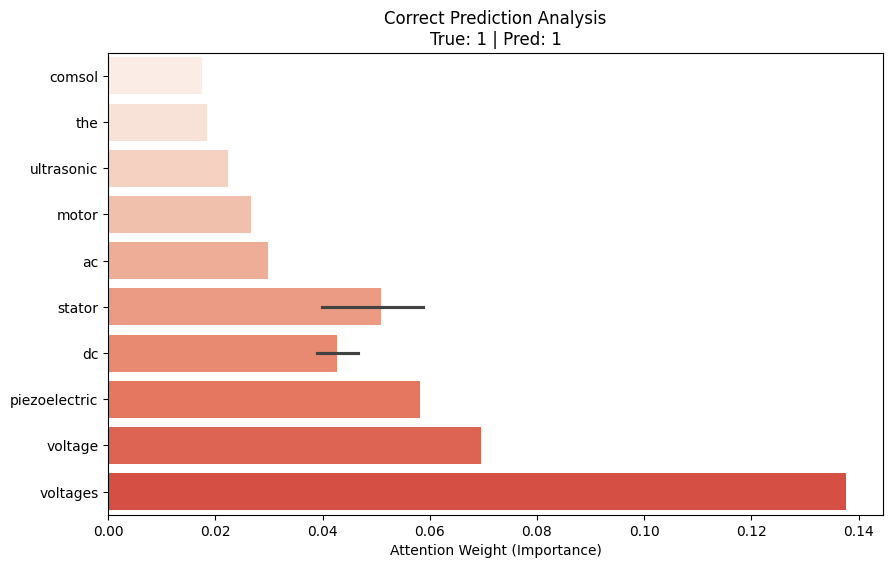

/tmp/ipython-input-702739245.py:95: UserWarning: The palette list has more values (15) than needed (8), which may not be intended.
  sns.barplot(x=top_weights, y=top_tokens, palette=colors, hue=top_tokens, legend=False)


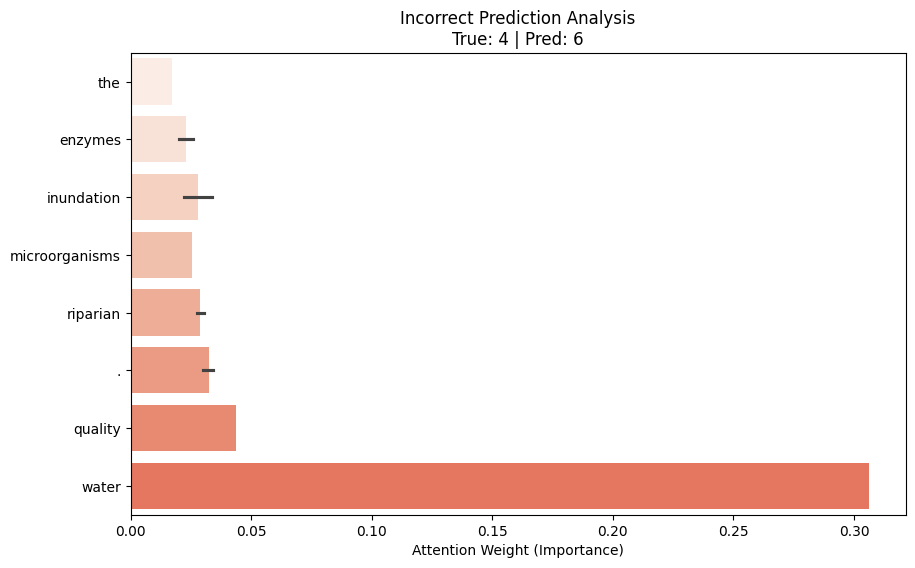

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch

def merge_subwords_and_score(tokens, attention_weights):
    """
    Merges BERT subwords (starting with ##) back into full words
    and aggregates their attention scores.
    """
    merged_tokens = []
    merged_weights = []

    current_word = ""
    current_weight = 0.0

    for token, weight in zip(tokens, attention_weights):
        # Skip special tokens for the clean list
        if token in ["[CLS]", "[SEP]", "[PAD]"]:
            continue

        if token.startswith("##"):
            # Merge with previous token
            current_word += token[2:]
            # Determine how to aggregate weight (sum or max or mean)
            # Summing captures total attention on the concept
            current_weight += weight
        else:
            # Save the previous word if it exists
            if current_word != "":
                merged_tokens.append(current_word)
                merged_weights.append(current_weight)

            # Start new word
            current_word = token
            current_weight = weight

    # Append the last word
    if current_word != "":
        merged_tokens.append(current_word)
        merged_weights.append(current_weight)

    return merged_tokens, np.array(merged_weights)

def visualize_attention(model, dataset, tokenizer, layer_id=11, head_id=0):
    model.eval()

    # 1. Get Batch
    loader = DataLoader(dataset, batch_size=32, shuffle=True)
    batch = next(iter(loader))

    input_ids = batch["input_ids"].to(device)
    attention_mask = batch["attention_mask"].to(device)
    labels = batch["y1"].to(device)

    logits_l1, _ = model(input_ids, attention_mask)
    preds = torch.argmax(logits_l1, dim=1)

    # 2. Find Indices
    correct_indices = (preds == labels).nonzero(as_tuple=True)[0]
    incorrect_indices = (preds != labels).nonzero(as_tuple=True)[0]

    if len(correct_indices) == 0 or len(incorrect_indices) == 0:
        print("Batch didn't contain both correct and incorrect examples. Run again.")
        return

    # 3. Plotting Helper
    def plot_top_k(idx, title, k=15):
        sample_input = input_ids[idx].unsqueeze(0)
        sample_mask = attention_mask[idx].unsqueeze(0)

        # Get Attention
        attentions = model.get_attention_map(sample_input, sample_mask)
        # Layer 11, Head 0, Row 0 ([CLS] attention)
        raw_attn = attentions[layer_id][0, head_id, 0, :].cpu().numpy()
        raw_tokens = tokenizer.convert_ids_to_tokens(sample_input[0])

        # Clean and Merge
        tokens, weights = merge_subwords_and_score(raw_tokens, raw_attn)

        # Get Top-K
        # Get indices of top k weights
        if len(weights) > k:
            top_indices = np.argsort(weights)[-k:]
        else:
            top_indices = np.argsort(weights)

        top_tokens = [tokens[i] for i in top_indices]
        top_weights = weights[top_indices]

        # Plot Horizontal Bar Chart (Easier to read)
        plt.figure(figsize=(10, 6))
        # Use a color palette mapped to the weight intensity
        colors = sns.color_palette("Reds", n_colors=len(top_weights))

        sns.barplot(x=top_weights, y=top_tokens, palette=colors, hue=top_tokens, legend=False)
        plt.title(f"{title}\nTrue: {labels[idx].item()} | Pred: {preds[idx].item()}")
        plt.xlabel("Attention Weight (Importance)")
        plt.show()

    print(f"--- Top 15 Most Attended Words (Layer {layer_id}, Head {head_id}) ---")
    plot_top_k(correct_indices[0], "Correct Prediction Analysis")
    plot_top_k(incorrect_indices[0], "Incorrect Prediction Analysis")

# Run it
visualize_attention(model, test_dataset_bert, tokenizer, layer_id=11, head_id=0)



## Extra Experiments


### Data starvation test

In [ ]:
import copy
import torch.optim as optim
from torch.utils.data import Subset

# --- Helper Function: Train BERT ---
def fit_bert(model, train_loader, epochs, lr, device):
    model.to(device)
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    # Ensure class weights are on the correct device
    crit_y1 = nn.CrossEntropyLoss(weight=class_weights_l1.to(device))
    crit_y2 = nn.CrossEntropyLoss(weight=class_weights_l2.to(device))

    model.train()
    for epoch in range(epochs):
        total_loss = 0
        for batch in train_loader:
            input_ids = batch["input_ids"].to(device)
            mask = batch["attention_mask"].to(device)
            y1 = batch["y1"].to(device)
            y2 = batch["y2"].to(device)

            optimizer.zero_grad()
            logits_l1, logits_l2 = model(input_ids, mask)

            loss = crit_y1(logits_l1, y1) + crit_y2(logits_l2, y2)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

In [ ]:
import copy

def run_data_efficiency_experiment(model_class, dataset_full, test_loader, model_type="LSTM"):
    # 1. Create a subset of only 10% of the training data
    subset_size = int(0.10 * len(dataset_full))
    print(f"\n--- EXPERIMENT: Training {model_type} on {subset_size} samples (10% Data) ---")

    # Randomly select indices
    subset_indices = torch.randperm(len(dataset_full))[:subset_size]
    train_subset = Subset(dataset_full, subset_indices)

    # Create loader for subset
    if model_type == "BERT":
        batch_size = 16
    else:
        batch_size = 64

    subset_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True)

    # 2. Instantiate fresh model
    if model_type == "LSTM":
        # Params: vocab_size, embed_dim, hidden, classes_y1, classes_y2
        model = LSTM(len(vocab), 300, 128, 7, 33).to(device)
        # LSTM has a built-in fit method
        model.fit(subset_loader, epochs=5, lr=0.001, device=device)
    else: # BERT
        model = BERT(7, 33).to(device)
        # Use our helper function for BERT
        fit_bert(model, subset_loader, epochs=3, lr=2e-5, device=device)

    # 3. Predict & Evaluate
    print(f"Evaluating {model_type}...")
    p1, p2 = model.predict(test_loader, device=device)

    # Assuming y1_test/y2_test are globally available as tensors or numpy arrays
    # Convert to numpy if they are tensors
    y1_true = y1_test.cpu().numpy() if isinstance(y1_test, torch.Tensor) else y1_test
    y2_true = y2_test.cpu().numpy() if isinstance(y2_test, torch.Tensor) else y2_test

    model.evaluate((y1_true, y2_true), (p1, p2))

# --- RUN THE EXPERIMENTS ---

# 1. Run for LSTM
# Ensure train_dataset_lstm exists
run_data_efficiency_experiment(LSTM, train_dataset_lstm, test_loader_lstm, "LSTM")

# 2. Run for BERT
# Ensure train_dataset_bert exists
run_data_efficiency_experiment(BERT, train_dataset_bert, test_loader_bert, "BERT")


--- EXPERIMENT: Training LSTM on 765 samples (10% Data) ---
Epoch 1/5, Loss: 5.3964
Epoch 2/5, Loss: 5.1177
Epoch 3/5, Loss: 4.6227
Epoch 4/5, Loss: 4.2974
Epoch 5/5, Loss: 3.9723
Evaluating LSTM...
Acc Y1: 0.5292, Acc Y2: 0.1612
F1 Y1: 0.4912, F1 Y2: 0.0892

--- EXPERIMENT: Training BERT on 765 samples (10% Data) ---
Evaluating BERT...
Accuracy for Y1: 0.7782
Accuracy for Y2: 0.3500
F1 score for Y1: 0.7687
F1 score for Y2: 0.2946


### Visualization of clustering

In [ ]:
# check current model
print(f"Current Model Class: {type(model).__name__}")

print(model)

Current Model Class: BERT
BERT(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1

Setting up models...
Epoch 1/5, Loss: 4.0196
Epoch 2/5, Loss: 2.7586
Epoch 3/5, Loss: 1.8708
Epoch 4/5, Loss: 1.2271
Epoch 5/5, Loss: 0.6594
Extracting LSTM features...
Extracting BERT features...
Running t-SNE (this might take a moment)...


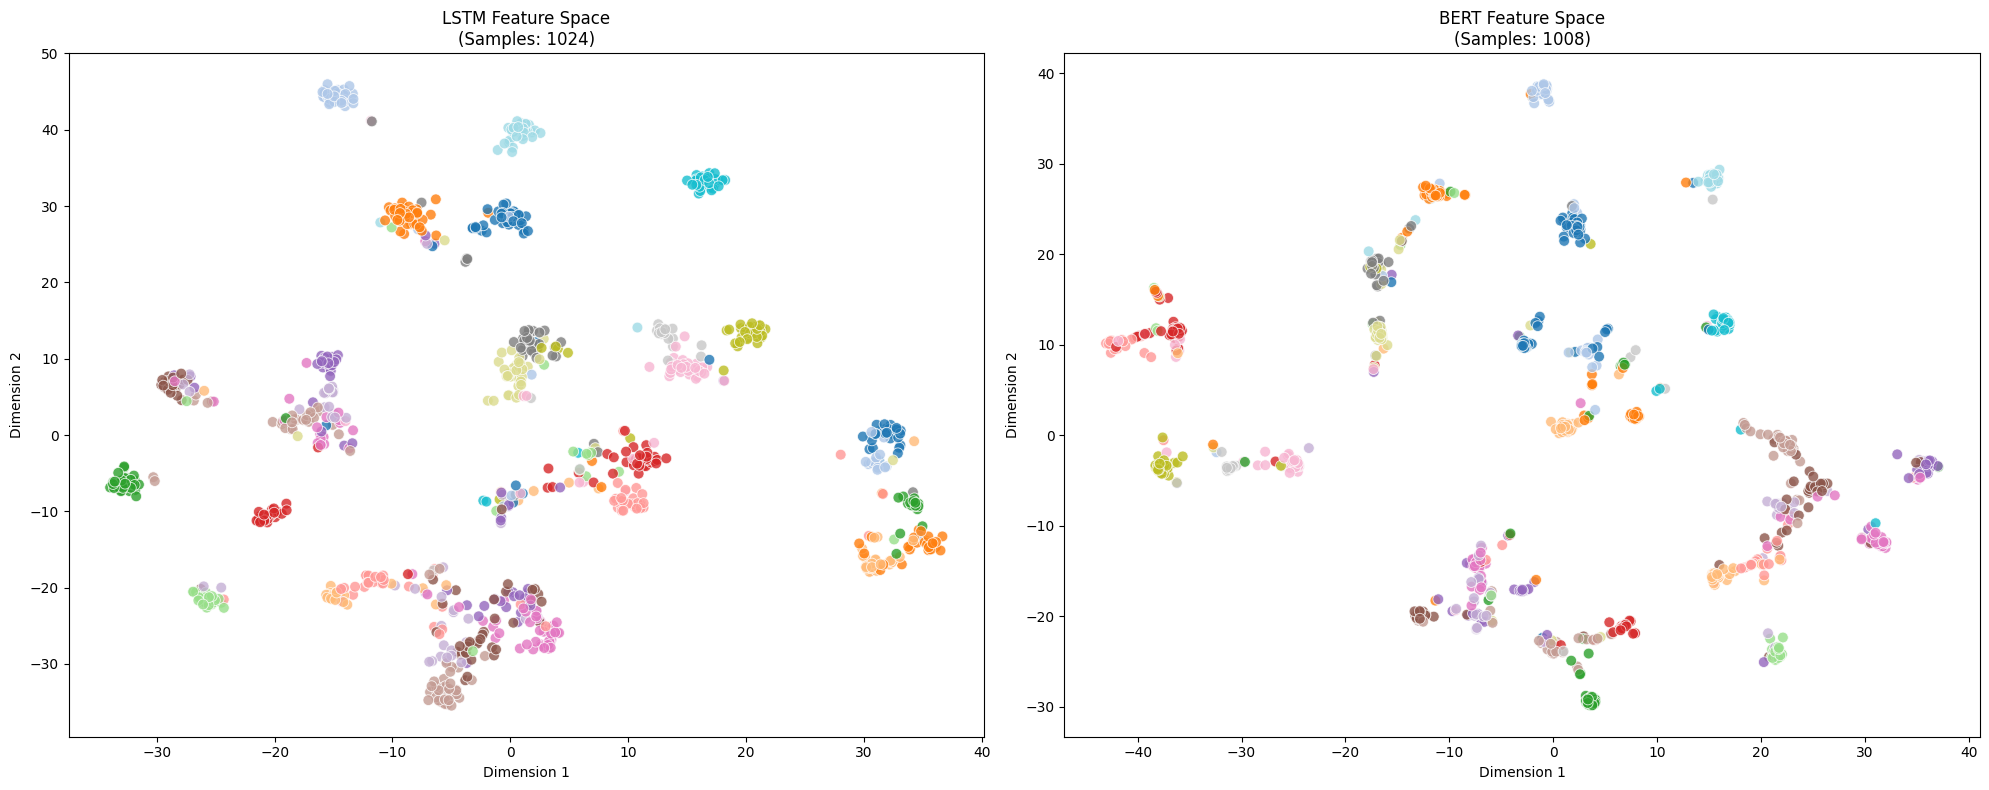

In [ ]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# --- Helper: Extract Features using Hooks ---
def extract_features(model, loader, device, limit=1000):
    model.eval()
    model.to(device)

    features_list = []
    labels_list = []

    # 1. Define a hook to capture the output of the dropout layer
    # (Both BERT and LSTM classes use self.dropout right before the classifier)
    activation = {}
    def get_activation(name):
        def hook(model, input, output):
            activation[name] = output.detach()
        return hook

    # Register the hook
    handle = model.dropout.register_forward_hook(get_activation('features'))

    count = 0
    with torch.no_grad():
        for batch in loader:
            if count >= limit: break

            # Prepare inputs based on loader type
            if isinstance(batch, dict): # BERT Dictionary
                input_ids = batch["input_ids"].to(device)
                mask = batch["attention_mask"].to(device)
                y = batch["y2"] # We visualize Sub-field classes
                model(input_ids, mask) # Run forward pass
            else: # LSTM Tuple
                x = batch[0].to(device)
                y = batch[2] # We visualize Sub-field classes (y2)
                model(x) # Run forward pass

            # The hook captures the data here!
            feats = activation['features']

            features_list.append(feats.cpu().numpy())
            labels_list.append(y.numpy())
            count += len(y)

    # Remove hook to clean up
    handle.remove()

    return np.concatenate(features_list), np.concatenate(labels_list)

# --- Helper: Run t-SNE and Plot ---
def run_tsne_comparison(lstm_model, bert_model, lstm_loader, bert_loader):
    print("Extracting LSTM features...")
    lstm_feats, lstm_labels = extract_features(lstm_model, lstm_loader, device)

    print("Extracting BERT features...")
    bert_feats, bert_labels = extract_features(bert_model, bert_loader, device)

    print("Running t-SNE (this might take a moment)...")
    tsne = TSNE(n_components=2, random_state=42, perplexity=30, init='pca', learning_rate='auto')

    # Compute t-SNE
    lstm_proj = tsne.fit_transform(lstm_feats)
    bert_proj = tsne.fit_transform(bert_feats)

    # Plotting
    fig, axes = plt.subplots(1, 2, figsize=(20, 8))

    # LSTM Plot
    sns.scatterplot(
        x=lstm_proj[:,0], y=lstm_proj[:,1],
        hue=lstm_labels, palette="tab20", legend=False,
        s=60, alpha=0.8, ax=axes[0]
    )
    axes[0].set_title(f"LSTM Feature Space\n(Samples: {len(lstm_labels)})")
    axes[0].set_xlabel("Dimension 1")
    axes[0].set_ylabel("Dimension 2")

    # BERT Plot
    sns.scatterplot(
        x=bert_proj[:,0], y=bert_proj[:,1],
        hue=bert_labels, palette="tab20", legend=False,
        s=60, alpha=0.8, ax=axes[1]
    )
    axes[1].set_title(f"BERT Feature Space\n(Samples: {len(bert_labels)})")
    axes[1].set_xlabel("Dimension 1")
    axes[1].set_ylabel("Dimension 2")

    plt.tight_layout()
    plt.show()

# --- EXECUTE ---
# Ensure 'model' variable currently holds the BERT model
# We need to temporarily reload LSTM if it's not in memory, or pass the specific variable names

print("Setting up models...")
temp_lstm = LSTM(len(vocab), 300, 128, 7, 33).to(device)
# run the LSTM training cell quickly before this.
temp_lstm.fit(train_loader_lstm, epochs=5, lr=0.001, device=device)

# Run Comparison
run_tsne_comparison(temp_lstm, model, test_loader_lstm, test_loader_bert)